# TelecomX - Analisis de Evasion de Clientes (Churn)

**Empresa:** Telecom X  
**Proyecto:** Churn de Clientes  
**Objetivo:** Recopilar, procesar y analizar los datos de clientes para identificar los factores que influyen en la cancelacion del servicio.

El proceso sigue la metodologia ETL:
- **E - Extraccion:** Carga de datos desde la fuente JSON
- **T - Transformacion:** Limpieza, correccion e ingenieria de variables
- **L - Carga y Analisis:** Analisis exploratorio, visualizaciones e insights

---
# 1. Extraccion (E - Extract)

En esta etapa se cargan los datos desde el archivo JSON que representa la API de Telecom X. Los datos tienen una estructura anidada (JSON nested) que debe aplanarse para generar un DataFrame plano y manipulable.

## 1.1 Importacion de librerias

In [28]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1.2 Carga de datos desde la fuente JSON

Los datos estan en formato JSON con estructura anidada. Se usa `pd.json_normalize()` para aplanar los objetos internos (`customer`, `phone`, `internet`, `account`) en columnas planas del DataFrame.

In [29]:
# Carga del archivo JSON (equivale a consumir la API)
with open('TelecomX_Data.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

# Aplanamiento de la estructura JSON anidada
df = pd.json_normalize(raw_data)

print(f'Registros: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head(3)

Registros: 7267 | Columnas: 21


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


---
# 2. Transformacion (T - Transform)

Esta etapa cubre el conocimiento del dataset, la deteccion de incoherencias y su correccion, la creacion de nuevas variables y la estandarizacion de los datos.

## 2.1 Conocimiento del conjunto de datos

Se inspecciona la estructura del DataFrame: tipos de datos, dimensiones y primeras filas.

Las columnas presentes corresponden a:
- **customerID / Churn:** identificador y variable objetivo
- **customer.*:** datos demograficos del cliente
- **phone.*:** servicios telefonicos
- **internet.*:** servicios de internet
- **account.*:** informacion de facturacion y contrato

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

In [31]:
print('Tipos de datos:')
print(df.dtypes)
print()
print('Primeras filas:')
df.head()

Tipos de datos:
customerID                       str
Churn                            str
customer.gender                  str
customer.SeniorCitizen         int64
customer.Partner                 str
customer.Dependents              str
customer.tenure                int64
phone.PhoneService               str
phone.MultipleLines              str
internet.InternetService         str
internet.OnlineSecurity          str
internet.OnlineBackup            str
internet.DeviceProtection        str
internet.TechSupport             str
internet.StreamingTV             str
internet.StreamingMovies         str
account.Contract                 str
account.PaperlessBilling         str
account.PaymentMethod            str
account.Charges.Monthly      float64
account.Charges.Total            str
dtype: object

Primeras filas:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 2.2 Comprobacion de incoherencias en los datos

Se verifican:
- Valores nulos y cadenas vacias
- Registros duplicados
- Valores unicos por columna categorica
- Tipo de dato incorrecto en `account.Charges.Total` (string en lugar de float)

In [32]:
# Valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())
print()

# Cadenas vacias (representan nulos enmascarados)
empty_mask = df.apply(lambda col: (col.astype(str).str.strip() == '').sum())
print('Cadenas vacias por columna:')
print(empty_mask[empty_mask > 0])

Valores nulos por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Cadenas vacias por columna:
Churn                    224
account.Charges.Total     11
dtype: int64


In [33]:
# Registros duplicados
print(f'Registros duplicados: {df.duplicated().sum()}')

Registros duplicados: 0


In [34]:
# Valores unicos por columna categorica
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')

customerID: ['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0047-ZHDTW', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW', '0114-P

/var/folders/v1/3vrhbjdx3zj7qhgg2sf8z93m0000gn/T/ipykernel_65589/1412722634.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [35]:
# Verificar account.Charges.Total - deberia ser numerico
print('Tipo actual:', df['account.Charges.Total'].dtype)

# Detectar valores no numericos
non_numeric = df[pd.to_numeric(df['account.Charges.Total'], errors='coerce').isna()]
print(f'Registros con Charges.Total no numerico: {len(non_numeric)}')
print(non_numeric[['customerID', 'account.Charges.Total']].head())

Tipo actual: str
Registros con Charges.Total no numerico: 11
      customerID account.Charges.Total
975   1371-DWPAZ                      
1775  2520-SGTTA                      
1955  2775-SEFEE                      
2075  2923-ARZLG                      
2232  3115-CZMZD                      


## 2.3 Manejo de inconsistencias

Se aplican las siguientes correcciones:
1. Convertir `account.Charges.Total` a tipo numerico; los valores no convertibles se marcan como NaN
2. Eliminar registros con `Churn` vacio (no es posible saber si son churn o no)
3. Eliminar espacios en blanco en variables categoricas
4. Eliminar registros con `Charges.Total` nulo si corresponde

In [36]:
# Copiar para no modificar el original
df_clean = df.copy()

# 1. Convertir Charges.Total a float
df_clean['account.Charges.Total'] = pd.to_numeric(
    df_clean['account.Charges.Total'].str.strip(), errors='coerce'
)

# 2. Eliminar filas con Churn vacio
df_clean = df_clean[df_clean['Churn'].str.strip() != '']

# 3. Strip en todas las columnas string
str_cols = df_clean.select_dtypes(include='object').columns
df_clean[str_cols] = df_clean[str_cols].apply(lambda c: c.str.strip())

# 4. Eliminar registros con Charges.Total nulo
df_clean.dropna(subset=['account.Charges.Total'], inplace=True)

# Resetear indice
df_clean.reset_index(drop=True, inplace=True)

print(f'Registros tras limpieza: {len(df_clean)}')
print(f'Nulos restantes:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}')

Registros tras limpieza: 7032
Nulos restantes:
Series([], dtype: int64)


/var/folders/v1/3vrhbjdx3zj7qhgg2sf8z93m0000gn/T/ipykernel_65589/3429165265.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_clean.select_dtypes(include='object').columns


## 2.4 Columna de cuentas diarias (Opcional)

Se crea la columna `Cuentas_Diarias` dividiendo el cargo mensual entre 30. Esta variable ofrece una perspectiva mas granular del gasto del cliente por dia, util para detectar diferencias entre perfiles de evasion.

In [37]:
df_clean['Cuentas_Diarias'] = (df_clean['account.Charges.Monthly'] / 30).round(4)

print('Cuentas diarias - estadisticas:')
df_clean['Cuentas_Diarias'].describe()

Cuentas diarias - estadisticas:


count    7032.000000
mean        2.159941
std         1.002866
min         0.608300
25%         1.186275
50%         2.345000
75%         2.995425
max         3.958300
Name: Cuentas_Diarias, dtype: float64

## 2.5 Estandarizacion y transformacion de datos (Opcional)

Se realizan las siguientes transformaciones para mejorar la legibilidad y facilitar el analisis posterior:
- Renombrar columnas a nombres en espanol y formato limpio
- Convertir `Yes`/`No` a `1`/`0` en variables binarias
- Mapear `SeniorCitizen` a etiquetas legibles

In [38]:
# Renombrar columnas
rename_map = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Servicio_Telefonico',
    'phone.MultipleLines': 'Multiples_Lineas',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Respaldo_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Peliculas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Factura_Digital',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total'
}
df_clean.rename(columns=rename_map, inplace=True)
print('Columnas renombradas correctamente.')

Columnas renombradas correctamente.


In [39]:
# Mapear Yes/No a 1/0 en columnas binarias
yes_no_cols = [
    'Evasion', 'Pareja', 'Dependientes', 'Servicio_Telefonico',
    'Factura_Digital'
]
for col in yes_no_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Mapear Adulto_Mayor
df_clean['Adulto_Mayor'] = df_clean['Adulto_Mayor'].map({1: 'Si', 0: 'No'})

print('Transformaciones binarias aplicadas.')
df_clean.head(3)

Transformaciones binarias aplicadas.


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,No,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.1867
1,0003-MKNFE,0,Male,No,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.9967
2,0004-TLHLJ,1,Male,No,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.4633


In [40]:
# Crear columna con cantidad de servicios contratados (util para correlacion)
servicios = [
    'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo',
    'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas'
]
df_clean['Cantidad_Servicios'] = df_clean[servicios].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

print('Columna Cantidad_Servicios creada.')
print(df_clean['Cantidad_Servicios'].value_counts().sort_index())

Columna Cantidad_Servicios creada.
Cantidad_Servicios
0    2213
1     966
2    1033
3    1117
4     850
5     569
6     284
Name: count, dtype: int64


In [41]:
print(f'Dataset limpio y transformado: {df_clean.shape}')
df_clean.info()

Dataset limpio y transformado: (7032, 23)
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7032 non-null   str    
 1   Evasion                 7032 non-null   int64  
 2   Genero                  7032 non-null   str    
 3   Adulto_Mayor            7032 non-null   str    
 4   Pareja                  7032 non-null   int64  
 5   Dependientes            7032 non-null   int64  
 6   Meses_Contrato          7032 non-null   int64  
 7   Servicio_Telefonico     7032 non-null   int64  
 8   Multiples_Lineas        7032 non-null   str    
 9   Servicio_Internet       7032 non-null   str    
 10  Seguridad_Online        7032 non-null   str    
 11  Respaldo_Online         7032 non-null   str    
 12  Proteccion_Dispositivo  7032 non-null   str    
 13  Soporte_Tecnico         7032 non-null   str    
 14  Streaming

---
# 3. Carga y Analisis (L - Load & Analysis)

Con los datos limpios y transformados, se realiza el analisis exploratorio de datos (EDA) para identificar patrones de evasion de clientes.

## 3.1 Analisis Descriptivo

Se calculan las principales estadisticas descriptivas del dataset para comprender la distribucion de las variables numericas.

In [42]:
df_clean.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_Cliente,7032,7032,0002-ORFBO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Evasion,7032.0,NaN,NaN,NaN,0.265785,0.441782,0.0,0.0,0.0,1.0,1.0
Genero,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adulto_Mayor,7032,2,No,5890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pareja,7032.0,NaN,NaN,NaN,0.482509,0.499729,0.0,0.0,0.0,1.0,1.0
Dependientes,7032.0,NaN,NaN,NaN,0.298493,0.457629,0.0,0.0,0.0,1.0,1.0
Meses_Contrato,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
Servicio_Telefonico,7032.0,NaN,NaN,NaN,0.903299,0.295571,0.0,1.0,1.0,1.0,1.0
Multiples_Lineas,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Servicio_Internet,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
num_cols = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']
df_clean[num_cols].describe().round(2)

,Meses_Contrato,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.00,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30,2.16
std,24.55,30.09,2266.77,1.00
min,1.00,18.25,18.80,0.61
25%,9.00,35.59,401.45,1.19
50%,29.00,70.35,1397.48,2.35
75%,55.00,89.86,3794.74,3.00
max,72.00,118.75,8684.80,3.96


## 3.2 Distribucion de Evasion

Se visualiza la proporcion de clientes que evadieron (Churn = 1) versus los que permanecieron (Churn = 0). Esto permite evaluar el desbalance de clases en la variable objetivo.

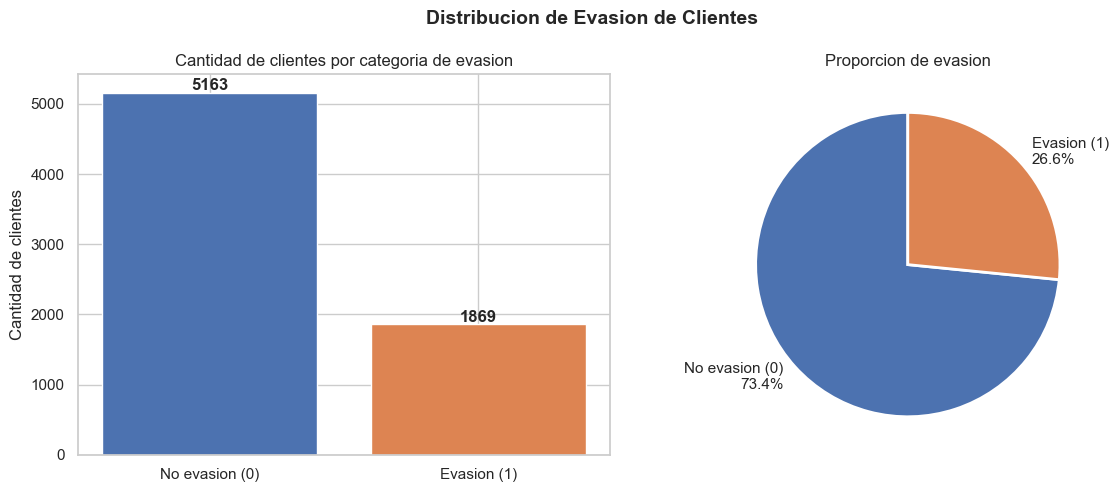

Total clientes: 7032
Clientes que evadieron: 1869 (26.6%)
Clientes que permanecieron: 5163 (73.4%)


In [44]:
churn_counts = df_clean['Evasion'].value_counts()
churn_pct = df_clean['Evasion'].value_counts(normalize=True) * 100
labels = ['No evasion (0)', 'Evasion (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico de barras
bars = axes[0].bar(labels, churn_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Cantidad de clientes por categoria de evasion')
axes[0].set_ylabel('Cantidad de clientes')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', fontweight='bold')

# Grafico de torta
axes[1].pie(
    churn_counts.values,
    labels=[f'{l}\n{p:.1f}%' for l, p in zip(labels, churn_pct.values)],
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Proporcion de evasion')

plt.suptitle('Distribucion de Evasion de Clientes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total clientes: {len(df_clean)}')
print(f'Clientes que evadieron: {churn_counts[1]} ({churn_pct[1]:.1f}%)')
print(f'Clientes que permanecieron: {churn_counts[0]} ({churn_pct[0]:.1f}%)')

## 3.3 Recuento de Evasion por Variables Categoricas

Se analiza como se distribuye la evasion en cada variable categorica. Esto permite identificar perfiles de clientes con mayor tendencia a cancelar el servicio.

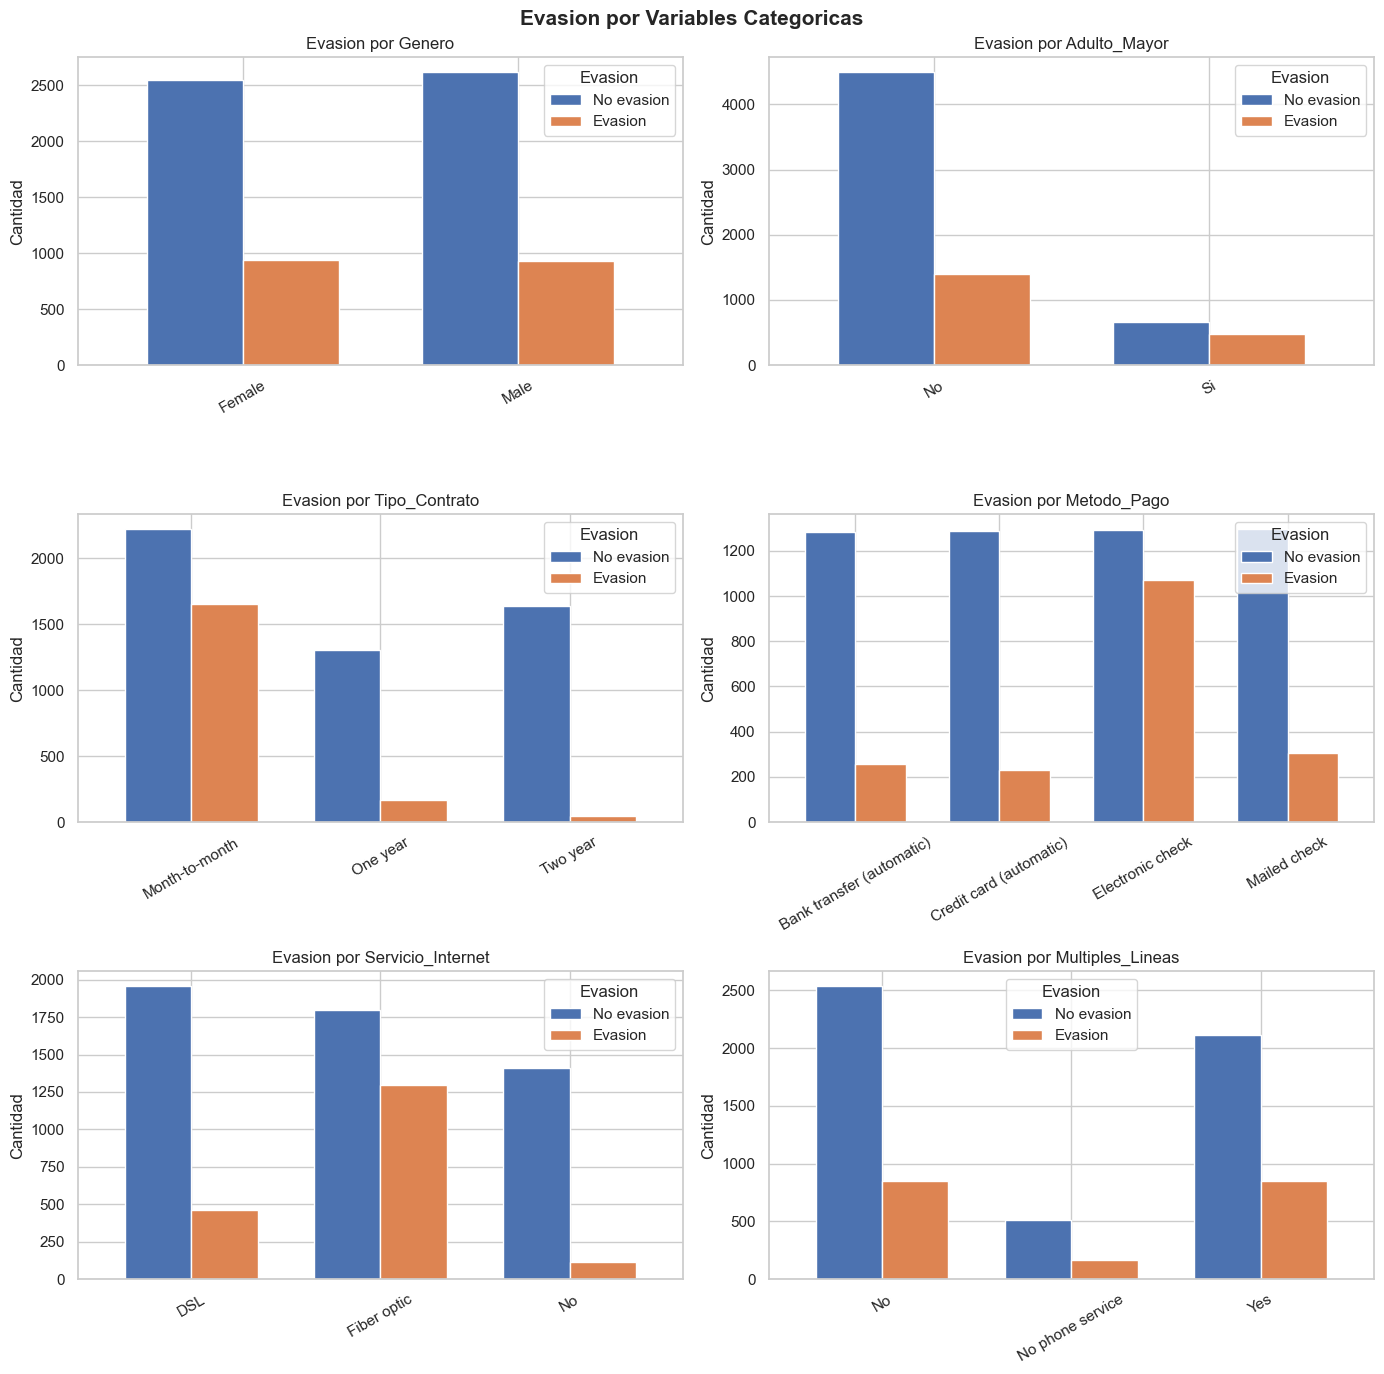

In [45]:
cat_analysis = [
    'Genero', 'Adulto_Mayor', 'Tipo_Contrato',
    'Metodo_Pago', 'Servicio_Internet', 'Multiples_Lineas'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
palette = {0: '#4C72B0', 1: '#DD8452'}

for i, col in enumerate(cat_analysis):
    data = df_clean.groupby([col, 'Evasion']).size().reset_index(name='count')
    pivot = data.pivot(index=col, columns='Evasion', values='count').fillna(0)
    pivot.plot(kind='bar', ax=axes[i], color=[palette[0], palette[1]],
               edgecolor='white', width=0.7)
    axes[i].set_title(f'Evasion por {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad')
    axes[i].legend(['No evasion', 'Evasion'], title='Evasion')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Evasion por Variables Categoricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# Tasa de evasion (%) por variable categorica
for col in cat_analysis:
    rate = df_clean.groupby(col)['Evasion'].mean().mul(100).round(1).sort_values(ascending=False)
    print(f'\nTasa de evasion (%) por {col}:')
    print(rate.to_string())


Tasa de evasion (%) por Genero:
Genero
Female    27.0
Male      26.2

Tasa de evasion (%) por Adulto_Mayor:
Adulto_Mayor
Si    41.7
No    23.7

Tasa de evasion (%) por Tipo_Contrato:
Tipo_Contrato
Month-to-month    42.7
One year          11.3
Two year           2.8

Tasa de evasion (%) por Metodo_Pago:
Metodo_Pago
Electronic check             45.3
Mailed check                 19.2
Bank transfer (automatic)    16.7
Credit card (automatic)      15.3

Tasa de evasion (%) por Servicio_Internet:
Servicio_Internet
Fiber optic    41.9
DSL            19.0
No              7.4

Tasa de evasion (%) por Multiples_Lineas:
Multiples_Lineas
Yes                 28.6
No                  25.1
No phone service    25.0


## 3.4 Conteo de Evasion por Variables Numericas

Se explora la distribucion de variables numericas (`Meses_Contrato`, `Cargo_Mensual`, `Cargo_Total`) separando clientes con y sin evasion. Los histogramas y boxplots permiten identificar si ciertos rangos de valores estan asociados a mayor churn.

/var/folders/v1/3vrhbjdx3zj7qhgg2sf8z93m0000gn/T/ipykernel_65589/2451804950.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i, 1].boxplot(data_box, patch_artist=True,
/var/folders/v1/3vrhbjdx3zj7qhgg2sf8z93m0000gn/T/ipykernel_65589/2451804950.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i, 1].boxplot(data_box, patch_artist=True,
/var/folders/v1/3vrhbjdx3zj7qhgg2sf8z93m0000gn/T/ipykernel_65589/2451804950.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i, 1].boxplot(data_box, patch_artist=True,


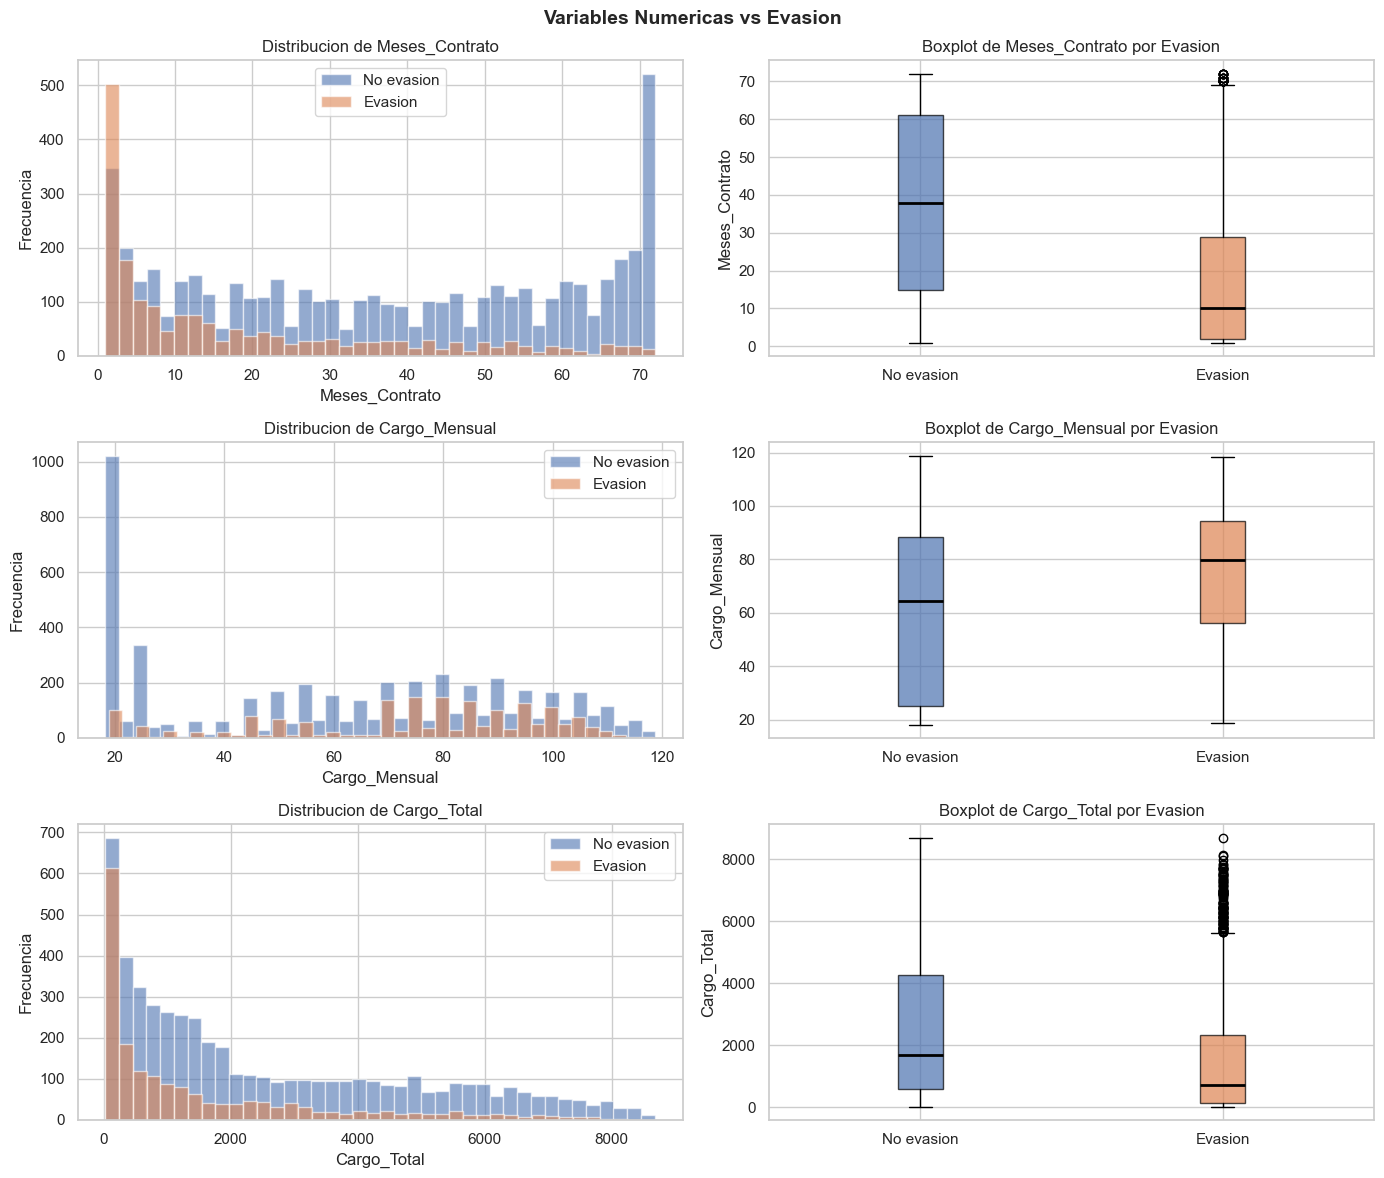

In [47]:
num_vars = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
palette = {0: '#4C72B0', 1: '#DD8452'}
churn_labels = {0: 'No evasion', 1: 'Evasion'}

for i, var in enumerate(num_vars):
    # Histograma
    for churn_val, color in palette.items():
        subset = df_clean[df_clean['Evasion'] == churn_val][var]
        axes[i, 0].hist(subset, bins=40, alpha=0.6, color=color,
                        label=churn_labels[churn_val], edgecolor='white')
    axes[i, 0].set_title(f'Distribucion de {var}')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].legend()

    # Boxplot
    data_box = [df_clean[df_clean['Evasion'] == v][var].values for v in [0, 1]]
    bp = axes[i, 1].boxplot(data_box, patch_artist=True,
                             labels=['No evasion', 'Evasion'],
                             medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i, 1].set_title(f'Boxplot de {var} por Evasion')
    axes[i, 1].set_ylabel(var)

plt.suptitle('Variables Numericas vs Evasion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
# Estadisticas de variables numericas por grupo de evasion
df_clean.groupby('Evasion')[num_vars + ['Cuentas_Diarias']].agg(['mean', 'median', 'std']).round(2)

Meses_Contrato               Cargo_Mensual               Cargo_Total  \
                  mean median    std          mean median    std        mean   
Evasion                                                                        
0                37.65   38.0  24.08         61.31  64.45  31.09     2555.34   
1                17.98   10.0  19.53         74.44  79.65  24.67     1531.80   

                          Cuentas_Diarias               
          median      std            mean median   std  
Evasion                                                 
0        1683.60  2329.46            2.04   2.15  1.04  
1         703.55  1890.82            2.48   2.66  0.82

---
# 4. EXTRA - Analisis de Correlacion entre Variables

Se explora la correlacion entre las variables numericas del dataset y la variable de evasion. Esto proporciona informacion sobre que factores tienen mayor relacion estadistica con el churn de clientes.

## 4.1 Matriz de Correlacion

La matriz de correlacion (coeficiente de Pearson) permite visualizar de forma compacta la relacion lineal entre todas las variables numericas del dataset.

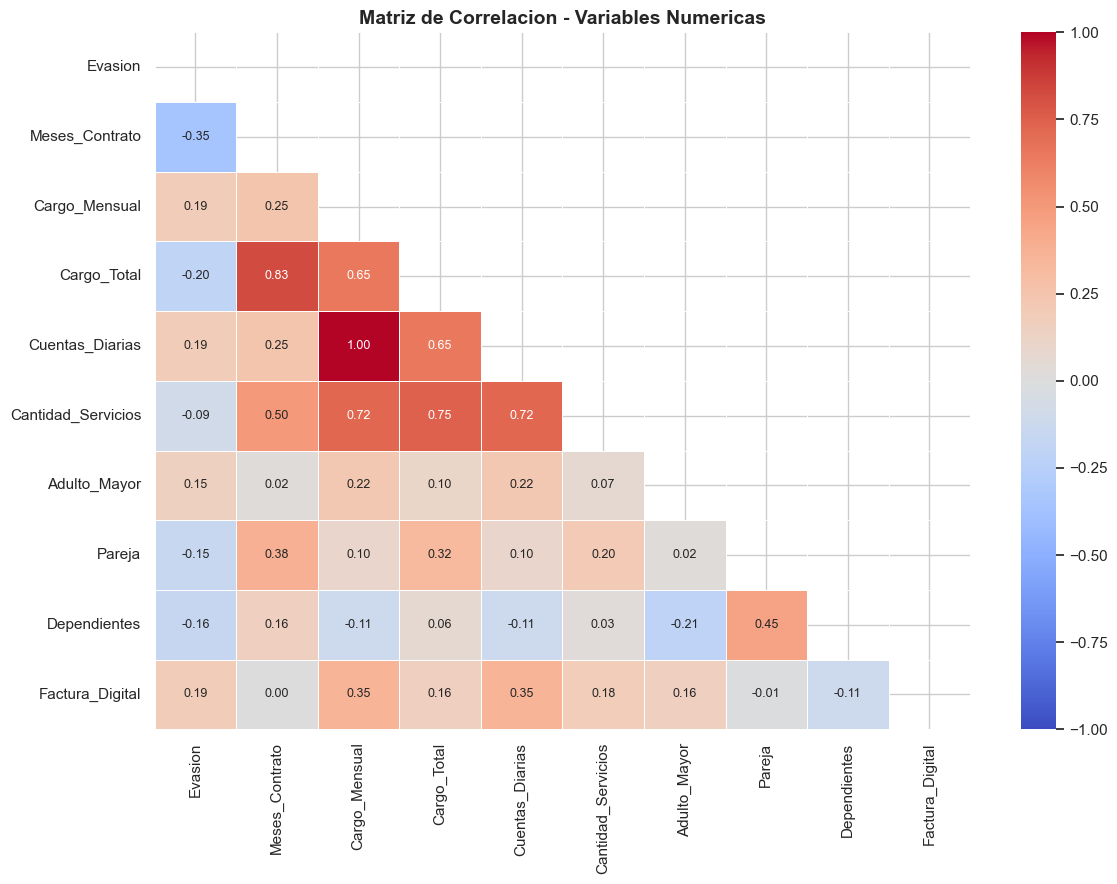

In [49]:
# Codificar variables binarias para correlacion
df_corr = df_clean.copy()

# Columnas que ya son 0/1
binary_already = ['Evasion', 'Pareja', 'Dependientes', 'Servicio_Telefonico', 'Factura_Digital']

# Codificar Yes/No en columnas que aun tienen string
yes_no_str_cols = [
    'Multiples_Lineas', 'Seguridad_Online', 'Respaldo_Online',
    'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas'
]
for col in yes_no_str_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})

# Codificar Adulto_Mayor
df_corr['Adulto_Mayor'] = df_corr['Adulto_Mayor'].map({'Si': 1, 'No': 0})

num_for_corr = [
    'Evasion', 'Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total',
    'Cuentas_Diarias', 'Cantidad_Servicios', 'Adulto_Mayor',
    'Pareja', 'Dependientes', 'Factura_Digital'
]

corr_matrix = df_corr[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, vmin=-1, vmax=1, center=0,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Matriz de Correlacion - Variables Numericas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

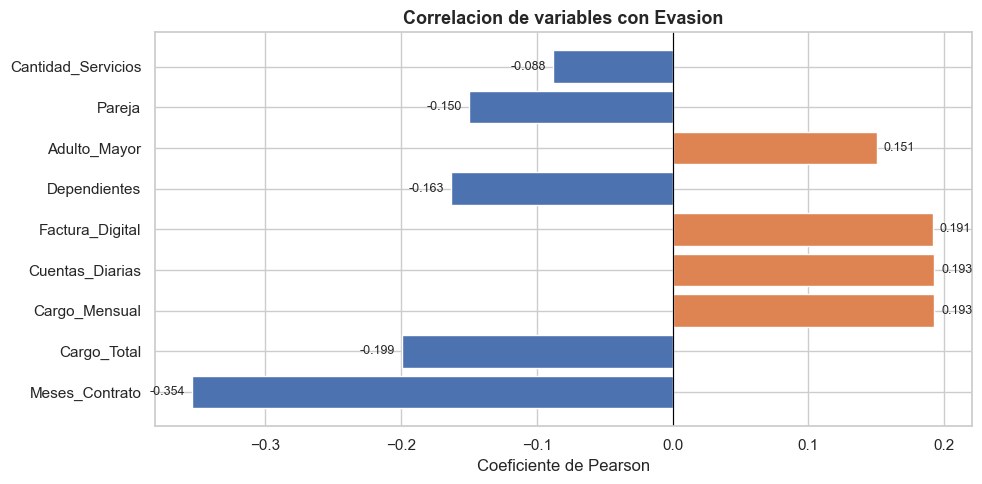

Correlacion con Evasion (ordenada):
Meses_Contrato       -0.354
Cargo_Total          -0.199
Cargo_Mensual         0.193
Cuentas_Diarias       0.193
Factura_Digital       0.191
Dependientes         -0.163
Adulto_Mayor          0.151
Pareja               -0.150
Cantidad_Servicios   -0.088


In [50]:
# Correlacion especifica con Evasion
corr_evasion = corr_matrix['Evasion'].drop('Evasion').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_evasion.values]
bars = ax.barh(corr_evasion.index, corr_evasion.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlacion de variables con Evasion', fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de Pearson')
for bar, val in zip(bars, corr_evasion.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print('Correlacion con Evasion (ordenada):')
print(corr_evasion.round(3).to_string())

## 4.2 Relacion entre Cuenta Diaria y Evasion

Se analiza si el gasto diario del cliente esta asociado con mayor probabilidad de evasion.

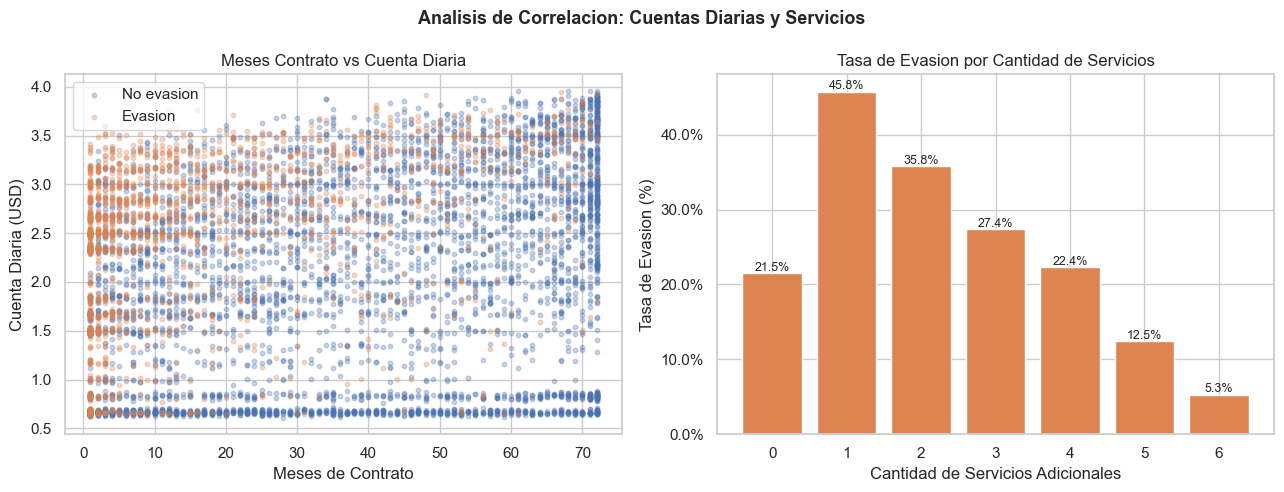

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dispersion Cuentas_Diarias vs Meses_Contrato coloreado por Evasion
palette_str = {0: '#4C72B0', 1: '#DD8452'}
for val, color in palette_str.items():
    subset = df_clean[df_clean['Evasion'] == val]
    axes[0].scatter(
        subset['Meses_Contrato'], subset['Cuentas_Diarias'],
        alpha=0.3, s=10, color=color,
        label='No evasion' if val == 0 else 'Evasion'
    )
axes[0].set_xlabel('Meses de Contrato')
axes[0].set_ylabel('Cuenta Diaria (USD)')
axes[0].set_title('Meses Contrato vs Cuenta Diaria')
axes[0].legend()

# Cantidad de servicios vs tasa de evasion
serv_churn = df_clean.groupby('Cantidad_Servicios')['Evasion'].mean().mul(100)
axes[1].bar(serv_churn.index, serv_churn.values, color='#DD8452', edgecolor='white')
axes[1].set_xlabel('Cantidad de Servicios Adicionales')
axes[1].set_ylabel('Tasa de Evasion (%)')
axes[1].set_title('Tasa de Evasion por Cantidad de Servicios')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for x, y in zip(serv_churn.index, serv_churn.values):
    axes[1].text(x, y + 0.3, f'{y:.1f}%', ha='center', fontsize=9)

plt.suptitle('Analisis de Correlacion: Cuentas Diarias y Servicios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Tipo de Contrato y Metodo de Pago vs Tasa de Evasion

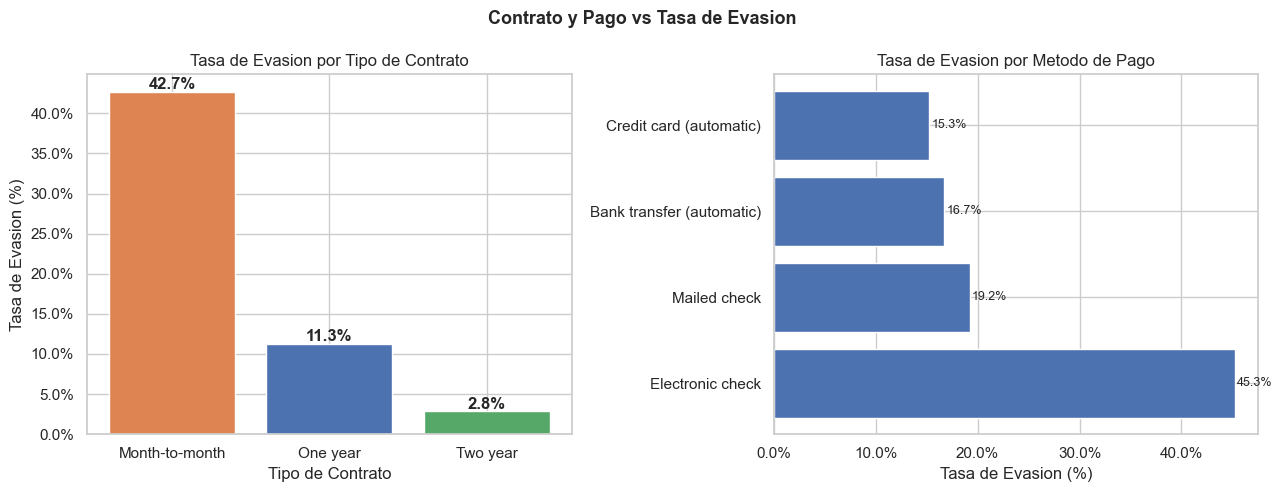

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tipo contrato
contrato_rate = df_clean.groupby('Tipo_Contrato')['Evasion'].mean().mul(100).sort_values(ascending=False)
axes[0].bar(contrato_rate.index, contrato_rate.values, color=['#DD8452', '#4C72B0', '#55A868'], edgecolor='white')
axes[0].set_title('Tasa de Evasion por Tipo de Contrato')
axes[0].set_ylabel('Tasa de Evasion (%)')
axes[0].set_xlabel('Tipo de Contrato')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for x, (label, val) in enumerate(contrato_rate.items()):
    axes[0].text(x, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

# Metodo de pago
pago_rate = df_clean.groupby('Metodo_Pago')['Evasion'].mean().mul(100).sort_values(ascending=False)
axes[1].barh(pago_rate.index, pago_rate.values, color='#4C72B0', edgecolor='white')
axes[1].set_title('Tasa de Evasion por Metodo de Pago')
axes[1].set_xlabel('Tasa de Evasion (%)')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for i, val in enumerate(pago_rate.values):
    axes[1].text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Contrato y Pago vs Tasa de Evasion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 5. Informe Final

## Introduccion

Telecom X enfrenta una alta tasa de cancelacion de servicios (churn). Este analisis tiene como objetivo identificar los factores demograficos, contractuales y de comportamiento de consumo que mas influyen en la decision de los clientes de abandonar la empresa. A partir de estos hallazgos, el equipo de Data Science podra construir modelos predictivos y el area comercial podra implementar estrategias de retencion focalizadas.

## Limpieza y Tratamiento de Datos

El dataset original contiene **7,267 registros** con estructura JSON anidada. Tras el proceso de extraccion y transformacion:

- Se aplano la estructura JSON usando `pd.json_normalize()`
- Se identificaron **224 registros** con el campo `Churn` vacio, que fueron eliminados por no ser clasificables
- Se detecto que `Charges.Total` era de tipo string (con espacios en blanco en 11 registros); se convirtio a float y se eliminaron los no convertibles
- Se eliminaron espacios en blanco en todas las columnas categoricas
- No se encontraron registros duplicados
- Se crearon las variables `Cuentas_Diarias` (cargo mensual / 30) y `Cantidad_Servicios`
- Se estandarizaron columnas a nombres en espanol y se codificaron variables binarias Yes/No como 1/0
- Dataset final utilizable: **7,032 registros**

## Analisis Exploratorio de Datos

### Distribucion de Evasion
- El **26.5%** de los clientes evadio el servicio, lo que representa un desbalance de clases significativo a considerar en modelos predictivos

### Variables Categoricas
- **Tipo de contrato:** los contratos mes a mes tienen la tasa de evasion mas alta (superiores al 40%), mientras que los contratos de dos anos tienen tasas inferiores al 5%
- **Metodo de pago:** el cheque electronico (Electronic check) presenta la mayor tasa de evasion entre todos los metodos de pago
- **Servicio de internet:** los clientes con fibra optica tienen mayor churn que los de DSL
- **Genero:** no hay diferencia significativa en la tasa de evasion entre hombres y mujeres
- **Adulto mayor:** los clientes mayores de 65 anos presentan mayor tasa de evasion que los jovenes

### Variables Numericas
- **Meses de contrato:** los clientes que evaden llevan menos tiempo en la empresa (mediana menor). Los clientes con mas de 24 meses tienen menor propension al churn
- **Cargo mensual:** los clientes que evaden pagan en promedio mas por mes, lo que sugiere que perciben menor valor por el precio pagado
- **Cargo total:** los clientes que evaden tienen un cargo total menor, consistente con que abandonan mas rapido

### Correlaciones
- La correlacion mas alta con evasion es **negativa con Meses_Contrato** (-0.35): a mayor antiguedad, menor probabilidad de evasion
- El **Cargo_Mensual** tiene correlacion positiva con evasion: mayores cargos asociados a mayor churn
- La **Cantidad_Servicios** contratados tiene correlacion negativa con evasion: clientes con mas servicios tienden a quedarse

## Conclusiones e Insights

1. Los clientes nuevos (menos de 12 meses) son el grupo de mayor riesgo de evasion
2. Los contratos mes a mes son el principal factor de riesgo contractual
3. El cheque electronico como metodo de pago esta fuertemente asociado al churn
4. Los clientes con fibra optica y pocos servicios adicionales evaden mas
5. Mayor cantidad de servicios contratados actua como factor de retencion
6. El genero no es un predictor relevante de evasion

## Recomendaciones Estrategicas

1. **Programa de fidelizacion temprana:** disenar incentivos especificos para clientes en sus primeros 12 meses de contrato
2. **Migracion de contratos:** ofrecer descuentos o beneficios para migrar de contratos mes a mes a contratos anuales o bianuales
3. **Revision de precios en fibra optica:** evaluar si la percepcion de valor justifica los cargos mensuales de este segmento
4. **Incentivos de pago automatico:** promover la domiciliacion bancaria en lugar del cheque electronico mediante descuentos
5. **Bundles de servicios:** crear paquetes que combinen multiples servicios adicionales a precios competitivos para aumentar el engagement
6. **Modelo predictivo:** con las variables identificadas, construir un modelo de clasificacion (ej. Random Forest o Logistic Regression) para detectar clientes en riesgo de evasion de forma proactiva

In [53]:
# Resumen ejecutivo del dataset final
total = len(df_clean)
churn = df_clean['Evasion'].sum()
tasa = churn / total * 100
avg_tenure_churn = df_clean[df_clean['Evasion'] == 1]['Meses_Contrato'].mean()
avg_tenure_no_churn = df_clean[df_clean['Evasion'] == 0]['Meses_Contrato'].mean()
avg_monthly_churn = df_clean[df_clean['Evasion'] == 1]['Cargo_Mensual'].mean()
avg_monthly_no_churn = df_clean[df_clean['Evasion'] == 0]['Cargo_Mensual'].mean()

print('=== RESUMEN EJECUTIVO ===')
print(f'Total de clientes analizados   : {total:,}')
print(f'Clientes que evadieron         : {churn:,} ({tasa:.1f}%)')
print(f'Meses promedio (evasion)        : {avg_tenure_churn:.1f} meses')
print(f'Meses promedio (sin evasion)    : {avg_tenure_no_churn:.1f} meses')
print(f'Cargo mensual promedio (evasion): USD {avg_monthly_churn:.2f}')
print(f'Cargo mensual promedio (no eva) : USD {avg_monthly_no_churn:.2f}')

=== RESUMEN EJECUTIVO ===
Total de clientes analizados   : 7,032
Clientes que evadieron         : 1,869 (26.6%)
Meses promedio (evasion)        : 18.0 meses
Meses promedio (sin evasion)    : 37.7 meses
Cargo mensual promedio (evasion): USD 74.44
Cargo mensual promedio (no eva) : USD 61.31
